### SARIMA on Air Passengers Data

#### Function to Check Stationarity Using Augmented Dickey-Fuller Test:

In [1]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

#### 1) Importing Necessary Libraries:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff

from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [3]:
df = pd.read_csv('airline_passengers.csv', index_col= 0, parse_dates= True)

In [4]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.shape

(144, 1)

In [6]:
df.describe()

,Thousands of Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Thousands of Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


##### Adding Index Frequency:

In [8]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [9]:
df.index.freq = 'MS'

In [10]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

##### Visualizing Data:

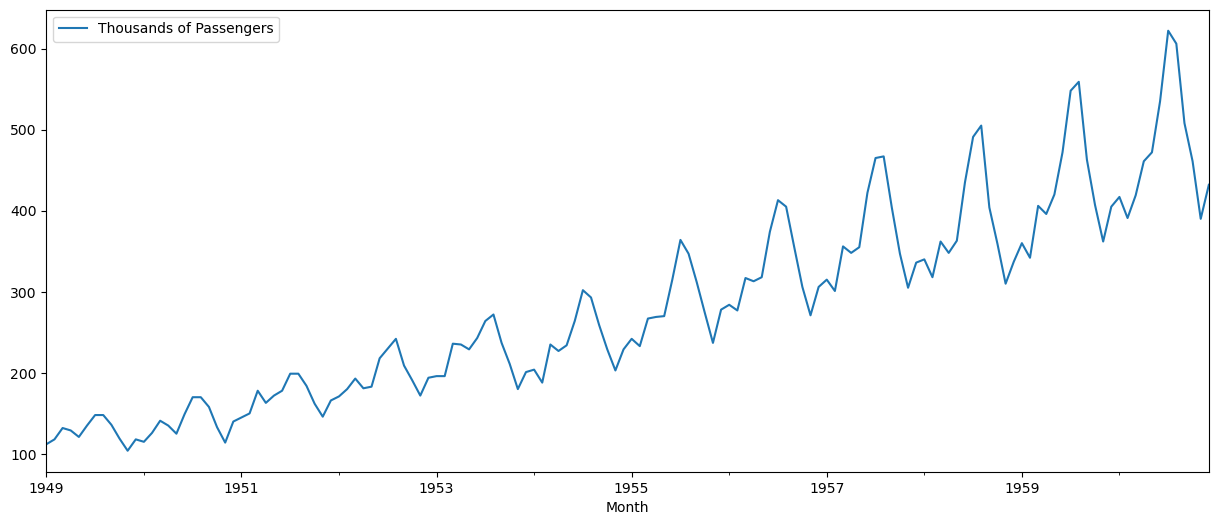

In [11]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

In [12]:
decomp = seasonal_decompose(df['Thousands of Passengers'], model= 'multiplicative')

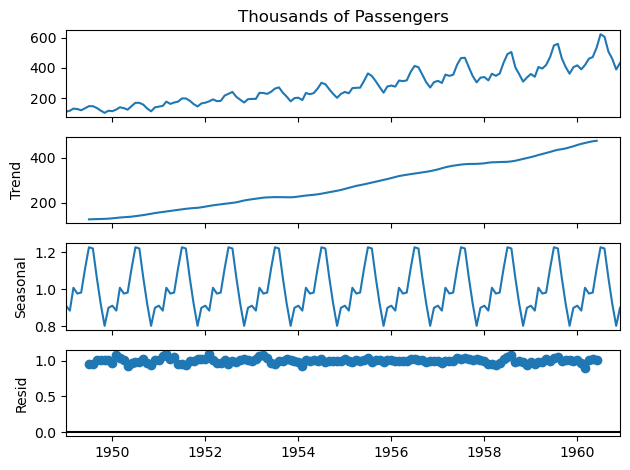

In [14]:
decomp.plot();

#### 4) Stationarity Check:

In [15]:
dickey_fuller_result(df['Thousands of Passengers'])

Test Statistics          0.815369
p-Value                  0.991880
No. of Lags             13.000000
No. of Observations    130.000000
Critical Value 1%       -3.481682
Critical Value 5%       -2.884042
Critical Value 10%      -2.578770
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


`Series is Non-Stationary.
We have to apply Differencing.`

In [16]:
df['Diff_1'] = diff(df['Thousands of Passengers'], k_diff= 1)
df.head()

,Thousands of Passengers,Diff_1
Month,,
1949-01-01,112,NaN
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0


In [17]:
# Checking Stationarity of First Order Differenced Data:

dickey_fuller_result(df["Diff_1"])

Test Statistics         -2.829267
p-Value                  0.054213
No. of Lags             12.000000
No. of Observations    130.000000
Critical Value 1%       -3.481682
Critical Value 5%       -2.884042
Critical Value 10%      -2.578770
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


In [18]:
# Applying Second Order Differencing:

df["Diff_2"] = diff(df["Thousands of Passengers"], k_diff= 2)
df.head()

,Thousands of Passengers,Diff_1,Diff_2
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,6.0,NaN
1949-03-01,132,14.0,8.0
1949-04-01,129,-3.0,-17.0
1949-05-01,121,-8.0,-5.0


In [19]:
# Checking Stationarity of Second Order Differenced Data:

dickey_fuller_result(df["Diff_2"])

Test Statistics       -1.638423e+01
p-Value                2.732892e-29
No. of Lags            1.100000e+01
No. of Observations    1.300000e+02
Critical Value 1%     -3.481682e+00
Critical Value 5%     -2.884042e+00
Critical Value 10%    -2.578770e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


#### 5) Deciding Order of p and q from ACF and PACF Plots:

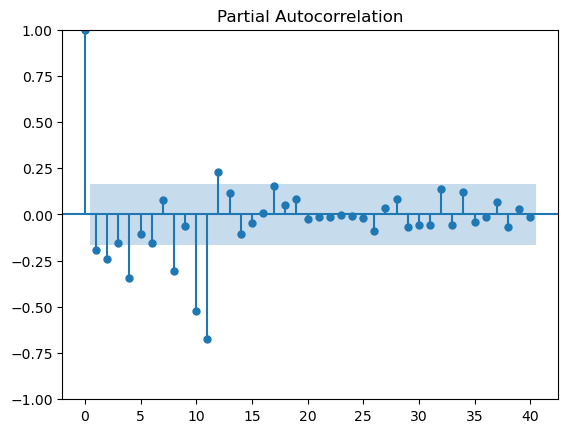

In [23]:
plot_pacf(df['Diff_2'].dropna(), lags= 40, method= 'ywm');

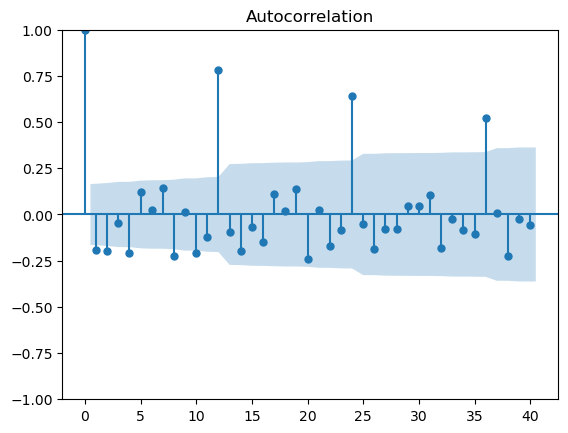

In [24]:
plot_acf(df['Diff_2'].dropna(), lags= 40);

`This confirms that data is Seasonal. A standard ARIMA $(p,d,q)$ will likely fail here because of those huge bumps at lag 12, 24 and 36 lags.`

#### 6) Using AUTO ARIMA for Deciding Orders:

In [25]:
grid = auto_arima(y= df['Thousands of Passengers'],
                 seasonal= True,
                 m= 12,
                 trace= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=1.56 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.27 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=1.17 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.28 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.86 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.08 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.19 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.69 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=1.01 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.55 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.06 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.06 sec
 ARIMA(3,1,1)(0,1,0

In [26]:
grid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Mon, 22 Dec 2025   AIC                           1017.847
Time:                                     18:21:21   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3126     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`(p, d, q)(P, D, Q)[m] = (2,1,1)(0,1,0)[12]`

#### 7) Train Test Split:

In [27]:
len(df)

144

In [28]:
train_data = df[:132]
test_data = df[132:]
print(train_data.shape, test_data.shape)

(132, 3) (12, 3)


#### 8) SARIMA(2,1,1)(0,1,0)[12] Model:

In [36]:
sarima = SARIMAX(endog= train_data['Thousands of Passengers'],
                order= (2, 1, 1),
                seasonal_order= (0, 1, 0, 12))

result = sarima.fit()

C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [37]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Mon, 22 Dec 2025   AIC                            902.967
Time:                                     18:27:15   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5253      0.929     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      0.275      0.040      0.968      -0.529       0.551
ma.L1          0.3064      0.935      0.328      0.743      -1.527       2.140
sigma2       108.0093     13.498      8.002      0.000      81.553     134.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.97   Prob(JB):                         0.50
Heteroskedasticity (H):               1.47   Skew:                            -0.09
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### Predictions on Test Data:

In [38]:
start = len(train_data)
end = len(train_data) + len(test_data) -1

sarima_pred = result.predict(start= start, end= end)

In [39]:
sarima_pred.head()

1960-01-01    425.135146
1960-02-01    408.815435
1960-03-01    471.901434
1960-04-01    462.399947
1960-05-01    486.128076
Freq: MS, Name: predicted_mean, dtype: float64

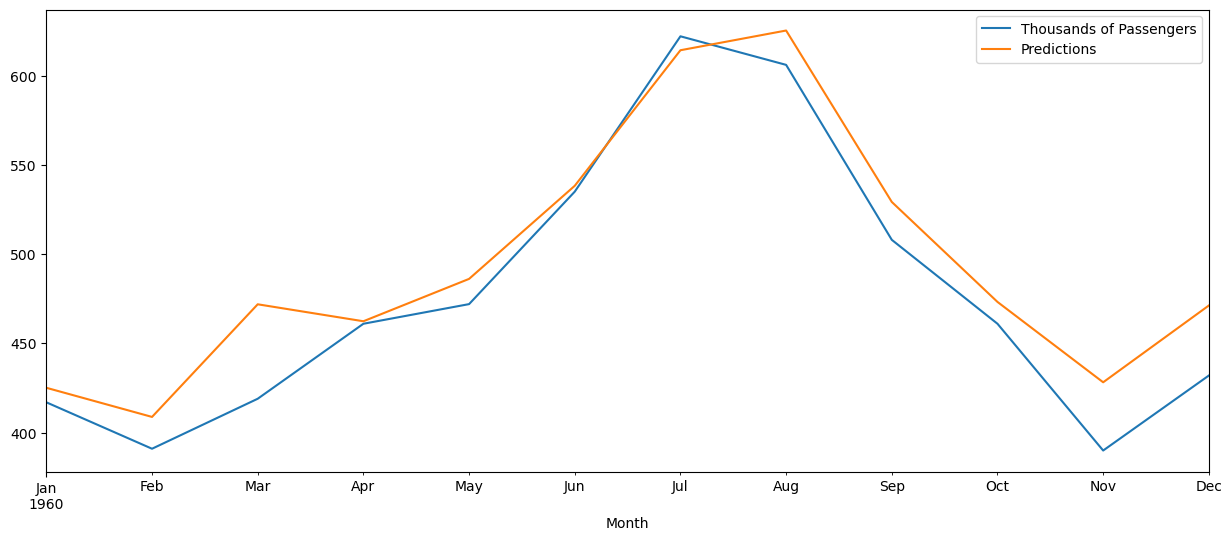

In [40]:
# Plotting Test Data and Predictions:

test_data["Thousands of Passengers"].plot(figsize= (15,6), legend= True)
sarima_pred.plot(label= "Predictions", legend= True)
plt.show()

In [41]:
# Model Evaluation:

np.sqrt(mean_squared_error(test_data["Thousands of Passengers"], sarima_pred))

np.float64(24.87410666603822)

##### Training Model on Full Data and Forecasting:

In [42]:
final_sarima = SARIMAX(df['Thousands of Passengers'],
                      order= (2, 1, 1),
                      seasonal_order= (0, 1, 0, 12))

results = final_sarima.fit()

C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [43]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Mon, 22 Dec 2025   AIC                           1017.847
Time:                                     18:28:11   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3126     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
# Forecasting:

forecast = results.predict(start= len(df),
                          end= len(df) + 11)
forecast.head()

1961-01-01    445.634842
1961-02-01    420.394881
1961-03-01    449.198158
1961-04-01    491.839751
1961-05-01    503.394249
Freq: MS, Name: predicted_mean, dtype: float64

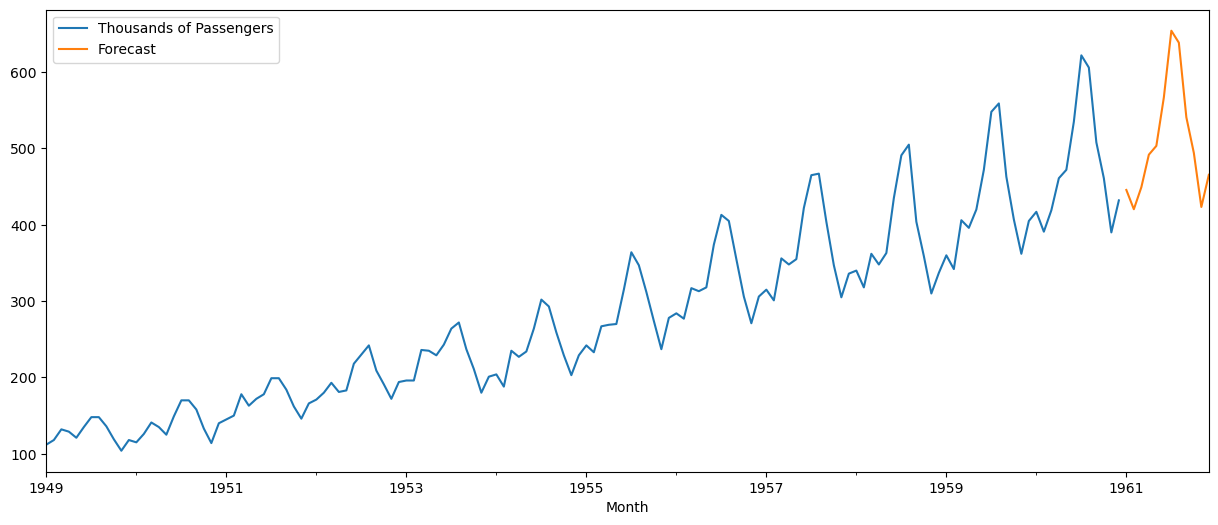

In [45]:
# Plotting Historic and Forecast Data:

df["Thousands of Passengers"].plot(figsize= (15,6), legend= True)
forecast.plot(label= "Forecast", legend= True)
plt.show()